### Lab: Analyzing Customer Behavior Dataset for a Retail Company


#### Problem Statement:
Retail companies collect vast amounts of customer data, including purchase patterns and demographic details. Analyzing this data helps businesses understand customer behavior, segment customers, and optimize marketing strategies. This lab focuses on exploring correlations, distributions, and relationships between different attributes using Pandas and visualization tools.

#### Objective:
- Load and explore a customer behavior dataset.
- Analyze purchase patterns based on demographics.
- Visualize correlations between different attributes.
- Identify trends and insights using Pandas and visualization tools.



#### Requirements:
- Python installed (version 3.x recommended).
- Pandas, NumPy, Matplotlib, and Seaborn installed (`pip install pandas numpy matplotlib seaborn`).
- Jupyter Notebook (optional but recommended for running the lab).
- Retail Sales Dataset from Kaggle: [Retail Sales Dataset](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset).


**Part 1: Importing Libraries and Loading Data**


In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
df = pd.read_csv("Dataset/retail_sales_dataset.csv")

print("Dataset Loaded Successfully")
df.head()


Dataset Loaded Successfully


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


**Part 2: Analyzing Demographic Trends**

In [3]:
# Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


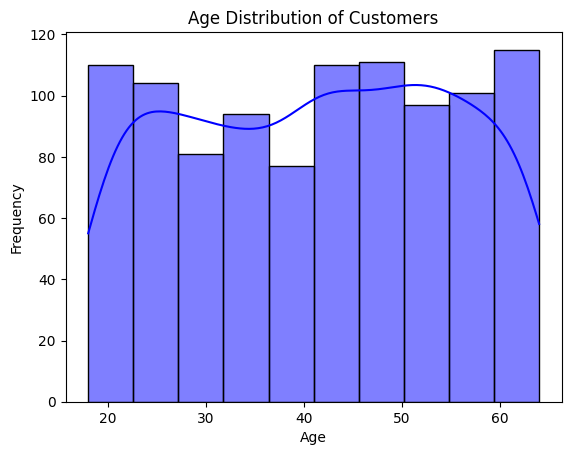

In [12]:
# Distribution of Age
sns.histplot(df['Age'].dropna(), bins=10, kde=True, color='blue')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


C:\Users\bhawa\AppData\Local\Temp\ipykernel_27036\2522661910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='coolwarm')


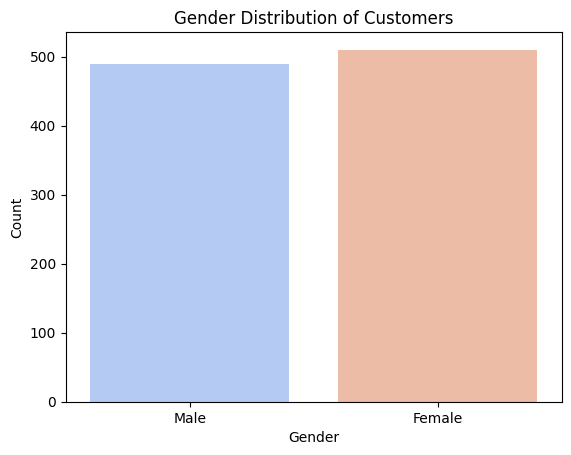

In [11]:
# Gender Distribution
sns.countplot(x='Gender', data=df, palette='coolwarm')
plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


**Part 3: Understanding Purchase Patterns**

C:\Users\bhawa\AppData\Local\Temp\ipykernel_27036\950203032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Product Category'].value_counts().index, y=df['Product Category'].value_counts(), palette='viridis')


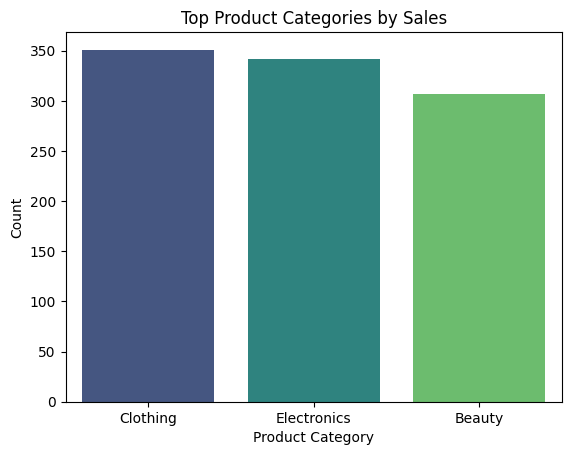

In [10]:
# Top Product Categories by Sales
sns.barplot(x=df['Product Category'].value_counts().index, y=df['Product Category'].value_counts(), palette='viridis')
plt.title('Top Product Categories by Sales')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()


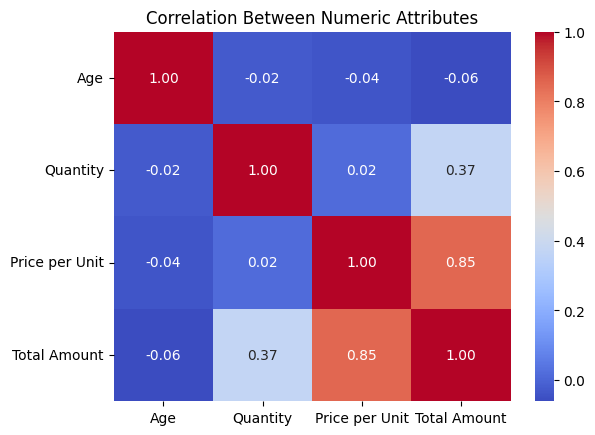

In [15]:
# Correlation heatmap
sns.heatmap(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Attributes')
plt.show()


**Part 4: Segmenting Customers Based on Spending**


In [16]:
# Customer Segmentation Based on Spending Category
def categorize_spending(amount):
    if amount >= df['Total Amount'].quantile(0.75):
        return 'High'
    elif amount >= df['Total Amount'].quantile(0.50):
        return 'Medium'
    else:
        return 'Low'

df['Spending_Category'] = df['Total Amount'].apply(categorize_spending)
print("Customer Segmentation Based on Spending Category:")
df[['Customer ID', 'Total Amount', 'Spending_Category']].head()


Customer Segmentation Based on Spending Category:


,Customer ID,Total Amount,Spending_Category
0,CUST001,150,Medium
1,CUST002,1000,High
2,CUST003,30,Low
3,CUST004,500,Medium
4,CUST005,100,Low


C:\Users\bhawa\AppData\Local\Temp\ipykernel_27036\2254791853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Spending_Category', data=df, palette='viridis')


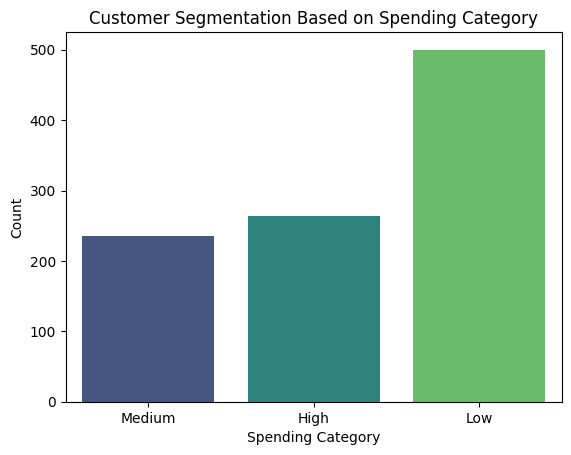

In [17]:
# plot the spending category
sns.countplot(x='Spending_Category', data=df, palette='viridis')
plt.title('Customer Segmentation Based on Spending Category')
plt.xlabel('Spending Category')
plt.ylabel('Count')
plt.show()